# AV1: Avaliação Individual

**Aluno(a):** Marcelo José Lopes Fragoso Filho

## Sobre esta avaliação

A AV1 cobre tudo que vimos nos Módulos 1 a 4. É uma avaliação de **integração**: o objetivo não é testar um tópico isolado, é você mostrar que consegue conduzir um problema de Machine Learning do começo ao fim, juntando as peças que aprendeu.

São **duas partes independentes**, com pesos iguais:

* **Parte A (50%):** um projeto completo de ML clássico (Módulos 1 a 3), prevendo a qualidade de vinhos.
* **Parte B (50%):** um exercício de deep learning (Módulo 4), classificando imagens reais.

Cada parte usa um dataset diferente. Faça as duas.

## Como você será avaliado

O que mais pesa é o seu **raciocínio**, não só o código rodar. Em cada etapa, além de fazer, você precisa **justificar** suas decisões com as próprias palavras. Um modelo que funciona mas que você não sabe explicar vale menos que um modelo simples bem compreendido.

Atenção aos pontos que valem nota em qualquer projeto de ML: separar treino e teste antes de tudo (sem leakage), usar pipeline, avaliar de forma honesta com as métricas certas, e interpretar os resultados com olhar crítico.

## Entrega

1. Complete as duas partes neste notebook
2. Salve com o nome `AV1_seunome.ipynb`
3. Suba no AVA dentro do prazo

---

# PARTE A: Projeto de ML Clássico (50%)

## Contexto

Você vai construir um modelo que prevê se um vinho é **bom** ou não, a partir de medidas físico-químicas. É um problema de **classificação binária** real, usado pela indústria pra controle de qualidade.

O dataset é o **Wine Quality (vinho tinto)**, do UCI. Cada linha é uma amostra de vinho, com 11 medidas químicas (acidez, açúcar, álcool, etc), e uma nota de qualidade dada por especialistas. Vamos considerar **bom** um vinho com nota maior ou igual a 7.

## Dicionário das variáveis

Todas as 11 features são numéricas (medidas químicas):

`fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`.

A coluna `quality` é a nota de 0 a 10. Você vai criar o alvo binário a partir dela.

## Atenção: classes desbalanceadas

Poucos vinhos são "bons" (nota >= 7). Isso significa que as classes são **desbalanceadas**, e como você viu na aula 12, a acurácia sozinha pode enganar nesse cenário. Você vai precisar olhar também precisão e recall.


## A.1 Carregar e explorar (Módulo 1)

Carregue o dataset, crie o alvo binário, e explore. Espera-se que você:
* Veja o tamanho, os tipos das colunas, e se há valores faltantes
* Crie a coluna alvo (`bom` = 1 se `quality` >= 7, senão 0)
* Veja a distribuição do alvo (qual a proporção de vinhos bons? as classes são equilibradas?)
* Faça pelo menos 2 visualizações que ajudem a entender os dados


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv"
df = pd.read_csv(url)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Crie o alvo binário: bom = 1 se quality >= 7, senão 0
df['bom'] = (df['quality'] >= 7).astype(int)
print(df[['quality','bom']].head())





   quality  bom
0        5    0
1        5    0
2        5    0
3        6    0
4        5    0


In [ ]:
# Explore: shape, info, faltantes, e a distribuição do alvo (qual % é bom?)
df.shape

(1599, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  bom                   1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


In [ ]:

df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df['bom'].value_counts()

,count
bom,
0,1382
1,217


In [ ]:
print((df['bom'].value_counts(normalize=True)*100)
.round(2).astype(str)+'%')

bom
0    86.43%
1    13.57%
Name: proportion, dtype: object


In [ ]:
perc_bom = df['bom'].mean() * 100
print(f'Percentual de vinhos bons: {perc_bom:.2f}%')

Percentual de vinhos bons: 13.57%


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>,
        <Axes: title={'center': 'residual sugar'}>],
       [<Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>,
        <Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>],
       [<Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>],
       [<Axes: title={'center': 'bom'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

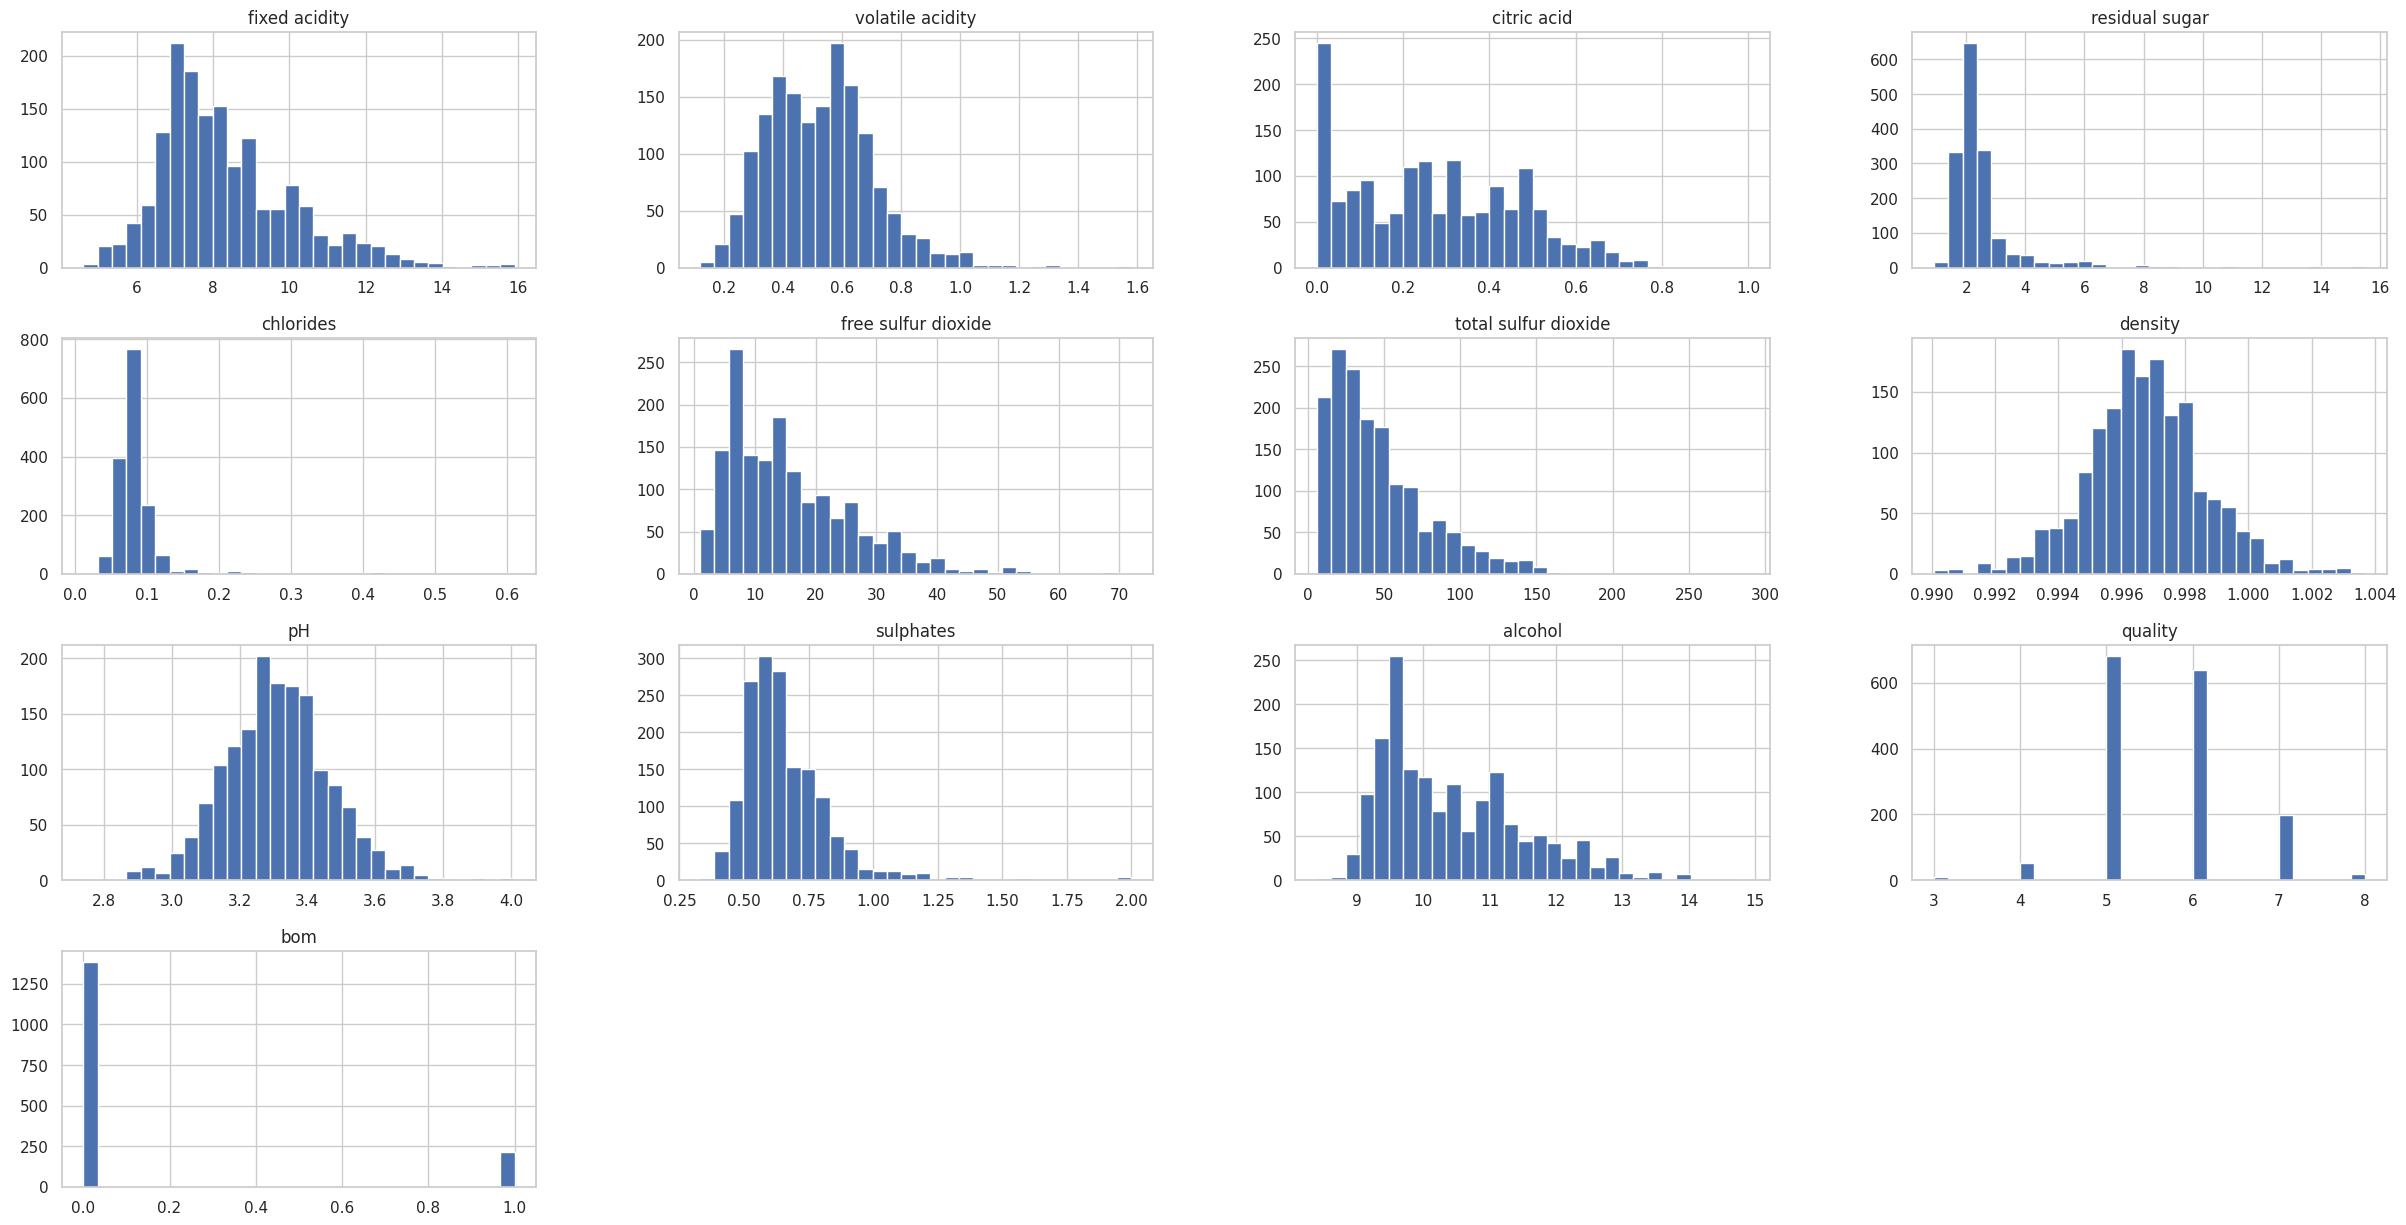

In [ ]:
# Pelo menos 2 visualizações (ex: distribuição do álcool por classe, correlações)

df.hist(bins=30,figsize=(30,15))

([<matplotlib.axis.XTick at 0x7b77af4ed7f0>,
 [Text(0, 0, 'Nao bom'), Text(1, 0, 'Bom')])

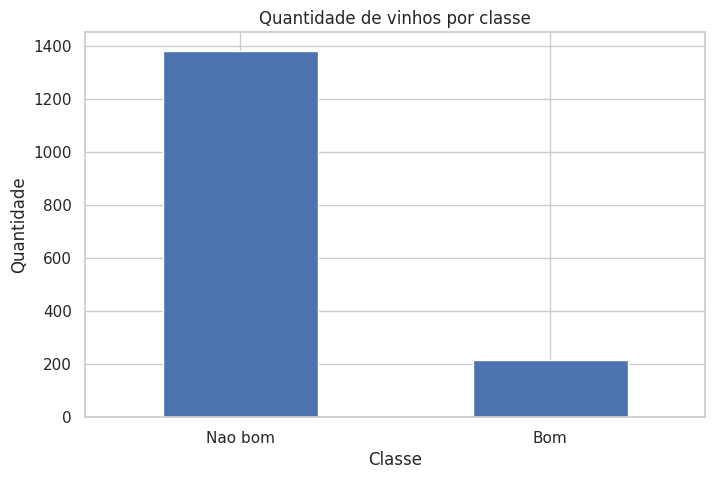

In [ ]:
plt.figure(figsize=(8,5))

df['bom'].value_counts().plot(kind='bar')

plt.title('Quantidade de vinhos por classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks([0,1],['Nao bom','Bom'],rotation=0)

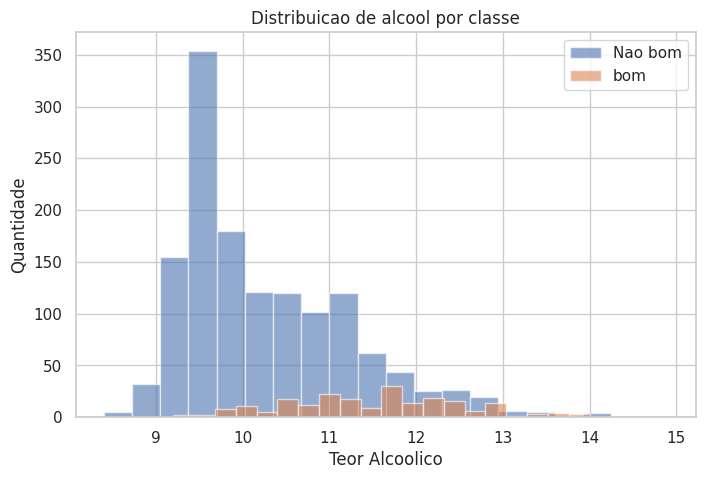

In [ ]:
#Esse gráfico ajuda a verificar se vinhos de melhor qualidade tendem a ter mais álcool.
plt.figure(figsize=(8,5))
df[df['bom']==0]['alcohol'].hist(alpha = 0.6, bins=20, label='Nao bom')
df[df['bom']==1]['alcohol'].hist(alpha = 0.6, bins=20, label='bom')

plt.xlabel('Teor Alcoolico')
plt.ylabel('Quantidade')
plt.title('Distribuicao de alcool por classe')
plt.legend()
plt.show()

<Axes: >

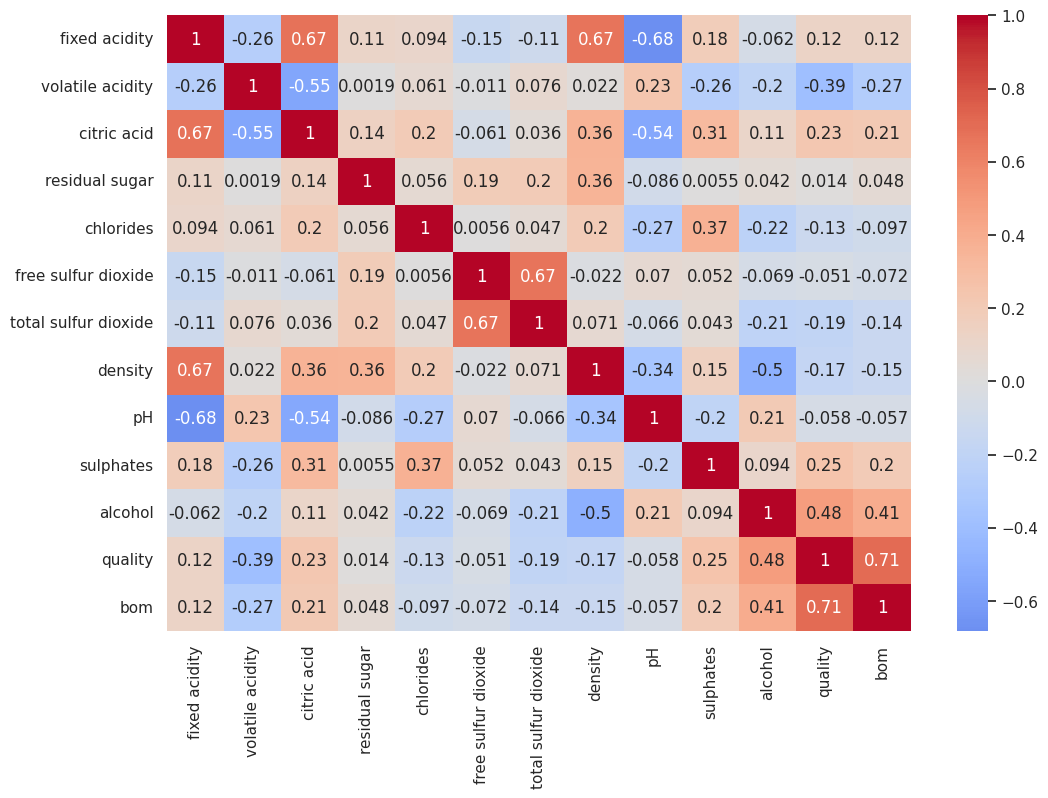

In [ ]:
#Matriz de correlaçao
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0
)

Text(0.5, 1.0, 'Álcool por classe')

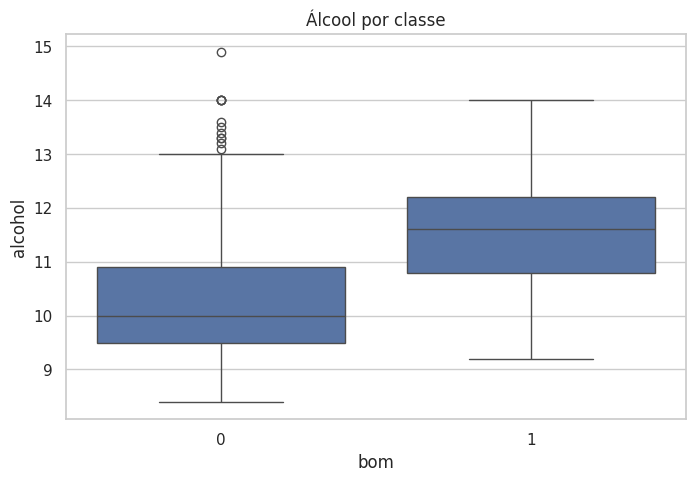

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bom', y='alcohol', data=df)

plt.title("Álcool por classe")

**Comente (A.1):** qual a proporção de vinhos bons? As classes estão desbalanceadas? Que implicação isso tem pra escolha da métrica de avaliação? Alguma variável química parece ter relação com a qualidade?

Aproximadamente 13,6% dos vinhos do conjunto de dados são classificados como bons (quality ≥ 7), enquanto 86,4% pertencem à classe de vinhos não bons. Isso caracteriza um conjunto de dados desbalanceado, o que torna a acurácia insuficiente como única métrica de avaliação, pois um modelo pode obter alta acurácia simplesmente prevendo a classe majoritária. Nesse cenário, métricas como precision, recall e F1-score são mais indicadas para avaliar o desempenho do modelo, principalmente na identificação dos vinhos de boa qualidade. Pela análise exploratória, matriz de correlacao e análise do boxplot observa-se que o teor alcoolico apresenta correlacao moderada com a qualidade dos vinhos(0.48).


## A.2 Preparar os dados (Módulo 2)

Prepare os dados pra modelagem:
* Separe treino e teste **antes** de qualquer transformação (pra evitar leakage)
* Use `stratify` pra manter a proporção das classes (importante aqui, já que é desbalanceado)
* Monte um **pipeline** com normalização das features (todas são numéricas)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separe X (as 11 features químicas) e y (a coluna 'bom')
X=df.drop(columns=['quality','bom'])
y=df['bom']
print(X.head())
print(y.head())

# Faça o split (sugestão: test_size=0.25, random_state=42, stratify=y)
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print("Treino",X_train.shape)
print("Teste:",X_test.shape)
# Monte o pré-processador com StandardScaler nas features numéricas
num_features = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_features)
    ]
)
print(preprocessor)



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  
0    0
1

**Comente (A.2):** por que o `stratify` é especialmente importante num dataset desbalanceado como este?

Como apenas cerca de 13,6% dos vinhos são classificados como bons, usar stratify garante que essa proporção seja mantida tanto no conjunto de treino quanto no de teste. Isso torna a avaliação do modelo mais representativa e evita que um dos conjuntos fique com poucas amostras da classe minoritária.

## A.3 Treinar e comparar modelos (Módulo 3)

Treine **três** modelos: uma regressão logística, um Random Forest e um XGBoost. Use o pipeline.

Compare os três com **validação cruzada**.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import xgboost as xgb
from xgboost import XGBClassifier

# Treine os 3 modelos e compare com cross_val_score
# XGBoost: xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')



###Pipelines



In [ ]:
#Regressao logistica

pipe_lr = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(random_state=42))
])

In [ ]:
#Random Forest

pipe_rf = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(random_state=42))
])

In [ ]:
#XGBoost

pipe_xgb = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [ ]:
modelos = {
    'Regressão Logística': pipe_lr,
    'Random Forest': pipe_rf,
    'XGBoost': pipe_xgb
}

resultados = []

for nome, modelo in modelos.items():

    score = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=5,
        scoring='f1'
    )

    resultados.append({
        'Modelo': nome,
        'F1 Médio': score.mean(),
        'Desvio': score.std()
    })

resultados = pd.DataFrame(resultados)

resultados

,Modelo,F1 Médio,Desvio
0,Regressão Logística,0.412100,0.092220
1,Random Forest,0.510262,0.052446
2,XGBoost,0.529777,0.041988


In [ ]:
resultados.sort_values(
    by='F1 Médio',
    ascending=False
)

,Modelo,F1 Médio,Desvio
2,XGBoost,0.529777,0.041988
1,Random Forest,0.510262,0.052446
0,Regressão Logística,0.412100,0.092220


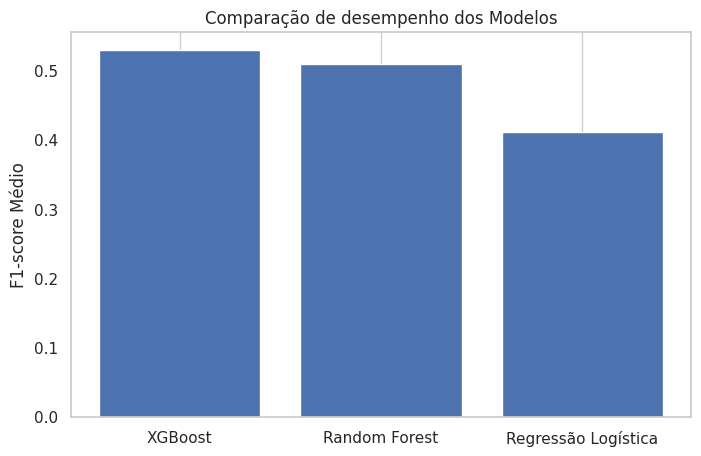

In [ ]:


resultados = resultados.sort_values(
    by='F1 Médio',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(resultados['Modelo'],
        resultados['F1 Médio'])

plt.ylabel("F1-score Médio")
plt.title("Comparação de desempenho dos Modelos")

plt.grid(axis='y')

plt.show()

**Comente (A.3):** qual modelo teve melhor desempenho na validação cruzada? A diferença entre a logística e os ensembles (RF e XGBoost) foi grande?

Na validação cruzada, o XGBoost apresentou o melhor desempenho, seguido pelo Random Forest, enquanto a Regressão Logística obteve o menor F1-score. Os modelos baseados em ensembles superaram a Regressão Logística por serem capazes de capturar relações não lineares entre as variáveis químicas e a qualidade do vinho. A diferença entre a Regressão Logística e os modelos de ensemble foi perceptível, indicando que métodos mais complexos conseguiram representar melhor o problema de classificação._

## A.4 Tunar um modelo (Módulo 3)

Escolha um dos modelos de árvore (RF ou XGBoost) e faça **uma** tunagem com `GridSearchCV` ou `RandomizedSearchCV`. Avalie se melhorou.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune um modelo e compare antes/depois
pipe_xgb = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}


grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)


print("Melhores parâmetros:")
print(grid_xgb.best_params_)

print("\nMelhor F1-score:")
print(grid_xgb.best_score_)


antes = resultados.loc[
    resultados['Modelo'] == 'XGBoost',
    'F1 Médio'
].values[0]

depois = grid_xgb.best_score_

print(f"F1 antes da tunagem : {antes:.4f}")
print(f"F1 depois da tunagem: {depois:.4f}")

if depois > antes:
    print(" O modelo melhorou após a tunagem.")
elif depois == antes:
    print(" O desempenho permaneceu o mesmo.")
else:
    print(" O desempenho piorou após a tunagem.")

Melhores parâmetros:
{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}

Melhor F1-score:
0.570827621628323
F1 antes da tunagem : 0.5298
F1 depois da tunagem: 0.5708
 O modelo melhorou após a tunagem.


**Comente (A.4):** a tunagem melhorou o desempenho?

O F1-score médio passou de 0,5298 para 0,5708, um aumento de aproximadamente 0,0411 pontos . Isso indica que a busca pelos melhores hiperparametros permitiu ao XGBoost encontrar uma configuracao mais adequada para o problema.

## A.5 Avaliação final com as métricas certas (Módulos 1 a 3 + métricas)

Escolha seu melhor modelo e avalie no **conjunto de teste**. Como o dataset é desbalanceado, **não basta olhar a acurácia**. Mostre:
* Acurácia, comparada com o baseline (chutar sempre a classe majoritária, ou seja, "não bom")
* **Precisão e recall** da classe "bom"
* A matriz de confusão

Compare também esses números com os da regressão logística. Aqui está o ponto central: olhe o que a acurácia esconde quando você compara com precisão e recall.


===== BASELINE =====
Acurácia: 0.865

===== XGBOOST =====
Acurácia : 0.94
Precisão : 0.8260869565217391
Recall   : 0.7037037037037037
F1-score : 0.76


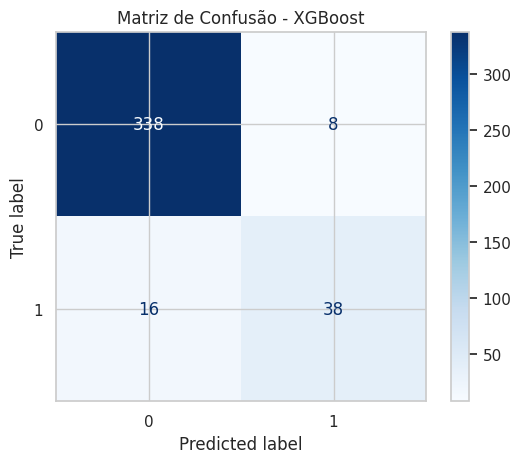


===== REGRESSÃO LOGÍSTICA =====
Acurácia : 0.8925
Precisão : 0.6896551724137931
Recall   : 0.37037037037037035
F1-score : 0.4819277108433735


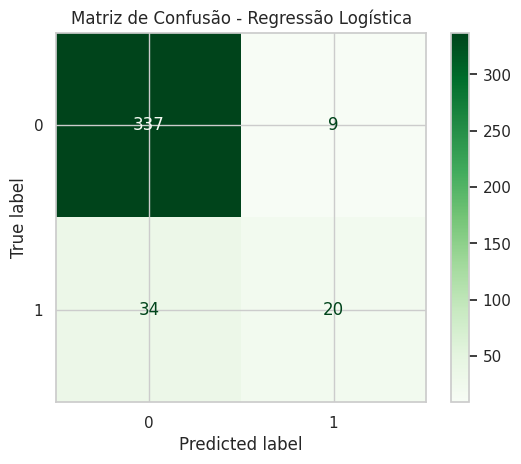

In [ ]:


# Avalie o melhor modelo no teste: acurácia, precisão, recall, F1, matriz de confusão
# Faça o mesmo pra logística e compare

melhor_modelo = grid_xgb.best_estimator_

y_pred_xgb = melhor_modelo.predict(X_test)

# Baseline (sempre prever "não bom")
baseline = [0] * len(y_test)

print("===== BASELINE =====")
print("Acurácia:", accuracy_score(y_test, baseline))

print("\n===== XGBOOST =====")
print("Acurácia :", accuracy_score(y_test, y_pred_xgb))
print("Precisão :", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Matriz de Confusão - XGBoost")
plt.show()


# Regressão Logística


pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)

print("\n===== REGRESSÃO LOGÍSTICA =====")
print("Acurácia :", accuracy_score(y_test, y_pred_lr))
print("Precisão :", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(cm_lr).plot(cmap="Greens")
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()


**Comente (A.5):** compare a logística com o seu melhor ensemble. Na acurácia, a diferença parece pequena ou grande? E quando você olha o **recall** (capacidade de encontrar os vinhos realmente bons)? O que a acurácia estava escondendo? Qual modelo você escolheria e por quê? _(escreva, esta é a reflexão mais importante da Parte A)_

A comparação entre a Regressao Logística e o XGBoost mostra que a diferença de acurácia existe, mas nao é tão expressiva quanto a diferença observada nas demais métricas. A Regressão Logística obteve uma acurácia de 89,25%, enquanto o XGBoost alcançou 94,0%, um ganho de aproximadamente 4,75 pontos percentuais.

No entanto, ao analisar o recall da classe "bom", percebe-se uma diferença muito mais significativa. A Regressao Logística apresentou recall de apenas 37,04%, ou seja, conseguiu identificar pouco mais de um terço dos vinhos realmente bons. Já o XGBoost alcançou recall de 70,37%, praticamente dobrando a capacidade de encontrar essa classe. Além disso, sua precisão também foi superior (82,61% contra 68,97%), indicando que, quando prevê que um vinho é bom, essa previsão tende a estar correta. O mesmo comportamento é observado no F1-score, que aumentou de 0,482 para 0,760, demonstrando um melhor equilíbrio entre precisão e recall.

Esses resultados mostram que a acurácia, sozinha, escondia uma limitaçao importante da Regressão Logística. Apesar de apresentar uma acurácia relativamente alta, ela deixava de identificar muitos vinhos realmente bons, provavelmente porque o conjunto de dados é desbalanceado e contém uma quantidade muito maior de vinhos classificados como "nao bons". Assim, um modelo pode acertar a maioria das amostras e ainda falhar justamente na classe de maior interesse.

Dessa forma, eu escolheria o XGBoost como modelo final. Além de apresentar a maior acurácia (94,0%), ele foi significativamente melhor na identificaçao dos vinhos realmente bons, obtendo maiores valores de precisão, recall e F1-score. Em problemas de classificação desbalanceados, essas métricas fornecem uma avaliação muito mais representativa do desempenho do modelo do que a acurácia isoladamente.



## A.6 Conclusão da Parte A

Escreva um parágrafo (6 a 10 linhas):
1. Qual modelo é o melhor pra esse problema, e como você justifica (com quais métricas)?
2. Por que os modelos de árvore (RF, XGBoost) superaram a regressão logística neste caso? (pense no tipo de relação entre as variáveis químicas e a qualidade)
3. Por que, neste dataset, a acurácia sozinha seria uma métrica enganosa?

O XGBoost foi o melhor modelo para este problema, pois apresentou os melhores resultados nas métricas mais importantes para um conjunto de dados desbalanceado: acurácia de 94,0%, precisão de 82,61%, recall de 70,37% e F1-score de 0,760, superando a Regressao Logística em todas elas. Os modelos baseados em árvores, como o Random Forest e o XGBoost, conseguiram desempenho superior porque são capazes de capturar relações complexas e nao lineares entre as características químicas do vinho e sua qualidade, além de modelar interaçoes entre as variáveis que a Regressao Logística, por ser um modelo linear, nao representa tão bem. Além disso, a acurácia sozinha seria uma métrica enganosa neste problema, pois o conjunto de dados é desbalanceado e a maioria dos vinhos pertence à classe "não bom". Isso faz com que um modelo possa apresentar uma acurácia elevada mesmo deixando de identificar muitos vinhos realmente bons. Por esse motivo, métricas como precisão, recall e F1-score fornecem uma avaliação muito mais confiável do desempenho dos modelos.



# PARTE B: Deep Learning com Imagens Reais (50%)

## Contexto

Agora você vai sair dos dados tabulares e trabalhar com **imagens reais**: fotos de cães e gatos. A tarefa é classificar cada foto como cachorro ou gato.

Você vai montar **duas redes** e compará-las: uma MLP (rede densa, da Aula 9) e uma CNN (rede convolucional, da Aula 10). O objetivo é você comprovar, na prática e com dados reais, a diferença entre as duas em imagem.

## Sobre o dataset

São fotos reais de cães e gatos, organizadas em pastas. O código de download e carregamento já está pronto nas células abaixo (não é o que está sendo avaliado, e evita que você trave antes de começar). O que você vai construir são as redes.

**Ative a GPU:** Ambiente de execução → Alterar tipo de ambiente de execução → GPU.


## B.1 Baixar e carregar o dataset (já pronto, só rode)

As células abaixo baixam as imagens e preparam os conjuntos de treino e teste. Rode e siga em frente.


In [ ]:
import urllib.request, zipfile, os

if not os.path.exists('/content/dogcat.zip'):
    url = "https://github.com/laxmimerit/dog-cat-full-dataset/archive/refs/heads/master.zip"
    urllib.request.urlretrieve(url, '/content/dogcat.zip')
    with zipfile.ZipFile('/content/dogcat.zip') as z:
        z.extractall('/content/')
    print("Dataset baixado e extraído.")
else:
    print("Dataset já existe.")

BASE = '/content/dog-cat-full-dataset-master/data'
print("Pastas:", os.listdir(BASE))

Dataset baixado e extraído.
Pastas: ['train', 'test']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

IMG = 128
BATCH = 32

train_ds = keras.utils.image_dataset_from_directory(
    f'{BASE}/train', image_size=(IMG, IMG), batch_size=BATCH, label_mode='int'
)
test_ds = keras.utils.image_dataset_from_directory(
    f'{BASE}/test', image_size=(IMG, IMG), batch_size=BATCH, label_mode='int'
)
nomes_classes = train_ds.class_names
print("Classes:", nomes_classes)

Found 19989 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Classes: ['cats', 'dogs']


## B.2 Visualizar algumas imagens

Rode pra ver com o que você está lidando. São fotos reais, de tamanhos e ângulos variados.


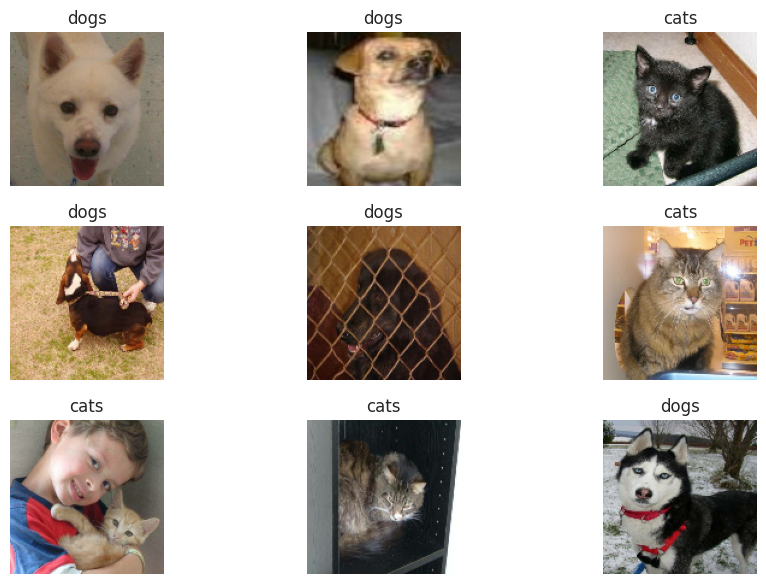

In [ ]:
plt.figure(figsize=(10, 6))
for imagens, rotulos in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(imagens[i].numpy().astype('uint8'))
        plt.title(nomes_classes[rotulos[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

## B.3 Normalizar

As redes treinam melhor com pixels entre 0 e 1. Aplique a normalização nos dois conjuntos.


In [ ]:
normalizar = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalizar(x), y))
test_ds = test_ds.map(lambda x, y: (normalizar(x), y))
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)
print("Normalizado.")

Normalizado.


## B.4 Montar e treinar uma MLP (Aula 9)

Monte uma rede **densa** (MLP) pra classificar as imagens. Como MLP não trabalha com imagem 2D direto, você precisa achatar a imagem primeiro (`layers.Flatten`).

Sugestão de arquitetura:
* `Flatten` na entrada (transforma a imagem 128x128x3 num vetor)
* Uma ou duas camadas densas com ReLU
* Camada de saída com 1 neurônio e ativação sigmoid (classificação binária)

Compile (otimizador adam, loss `binary_crossentropy`) e treine por umas 10 épocas.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Monte, compile e treine a MLP
# Dica de entrada: layers.Input(shape=(IMG, IMG, 3)) seguido de layers.Flatten()


# Modelo MLP


mlp = keras.Sequential([
    layers.Input(shape=(IMG, IMG, 3)),
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])


# Compilação


mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Visualizar arquitetura
mlp.summary()


# Treinamento


history_mlp = mlp.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,616,193 (48.13 MB)

 Trainable params: 12,616,193 (48.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.5444 - loss: 1.1096 - val_accuracy: 0.5796 - val_loss: 0.6699
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5764 - loss: 0.6837 - val_accuracy: 0.5542 - val_loss: 0.6800
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5820 - loss: 0.6729 - val_accuracy: 0.5914 - val_loss: 0.6714
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5927 - loss: 0.6700 - val_accuracy: 0.5758 - val_loss: 0.6771
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5893 - loss: 0.6683 - val_accuracy: 0.5760 - val_loss: 0.6745
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5755 - loss: 0.6748 - val_accuracy: 0.5838 - val_loss: 0.6720
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5994 - loss: 0.6661 - val_accuracy: 0.5778 - val_loss: 0.6755
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5875 - loss: 0.6711 - val_accuracy:

**Comente (B.4):** qual acurácia a MLP atingiu? Ela teve dificuldade? _(escreva)

A MLP atingiu uma acurácia máxima de 60,52% no conjunto de validação durante a 9ª época, encerrando o treinamento com 59,36% de acurácia de validaçao. Esse desempenho indica que a rede teve dificuldades para classificar corretamente as imagens. Isso ocorre porque uma MLP utiliza a camada Flatten, transformando a imagem em um vetor e perdendo a estrutura espacial dos pixels. Dessa forma, ela não consegue explorar padrões locais, como bordas, texturas e formas, que são fundamentais para tarefas de classificaçao de imagens. Por esse motivo, espera-se que seu desempenho seja inferior ao de uma CNN, que foi projetada especificamente para extrair características visuais por meio de camadas convolucionais._

## B.5 Montar e treinar uma CNN (Aula 10)

Agora monte uma **CNN**. Use o padrão que vimos: blocos de convolução + pooling, depois flatten e densa.

Sugestão de arquitetura:
* Entrada 128x128x3
* 2 ou 3 blocos de `Conv2D` (com ReLU) + `MaxPooling2D`
* `Flatten`
* Camada densa com ReLU
* Saída com 1 neurônio e sigmoid

Compile e treine por umas 10 épocas (com GPU, é rápido).


In [ ]:
# Monte, compile e treine a CNN


# Modelo CNN


cnn = keras.Sequential([
    layers.Input(shape=(IMG, IMG, 3)),

    # Bloco 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Bloco 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Bloco 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Classificador
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),      # ajuda a reduzir overfitting
    layers.Dense(1, activation='sigmoid')
])


# Compilação


cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar arquitetura
cnn.summary()


# Treinamento


history_cnn = cnn.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.6108 - loss: 0.6490 - val_accuracy: 0.7094 - val_loss: 0.5724
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7404 - loss: 0.5244 - val_accuracy: 0.7858 - val_loss: 0.4491
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8029 - loss: 0.4361 - val_accuracy: 0.8110 - val_loss: 0.4136
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8401 - loss: 0.3654 - val_accuracy: 0.8336 - val_loss: 0.3842
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8677 - loss: 0.3091 - val_accuracy: 0.8246 - val_loss: 0.4042
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8932 - loss: 0.2555 - val_accuracy: 0.8342 - val_loss: 0.4065
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9101 - loss: 0.2169 - val_accuracy: 0.8262 - val_loss: 0.4469
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9288 - loss: 0.1748 - 

**Comente (B.5):** qual acurácia a CNN atingiu? Como foi comparada à MLP? _(escreva)_

A CNN atingiu uma acurácia de validacão significativamente maior do que a MLP, alcançando um pico de aproximadamente 83,42% , Comparada à MLP, que obteve cerca de 60.5% de acurácia, a CNN demonstrou uma performance muito superior. Isso prova a eficácia das redes convolucionais em tarefas de classificação de imagens, pois elas são capazes de extrair características espaciais importantes, como bordas e texturas, que são essenciais para identificar objetos em imagens.

## B.6 Comparar MLP vs CNN

Compare as duas redes de forma clara (uma tabela ou gráfico com as acurácias de teste). Mostre a diferença.


In [ ]:
# Compare as duas redes



In [ ]:
mlp_accuracy = history_mlp.history['val_accuracy'][-1]
cnn_accuracy = history_cnn.history['val_accuracy'][-1]

comparison_df = pd.DataFrame({
    'Model': ['MLP', 'CNN'],
    'Test Accuracy': [mlp_accuracy, cnn_accuracy]
})

display(comparison_df)

,Model,Test Accuracy
0,MLP,0.5936
1,CNN,0.8132


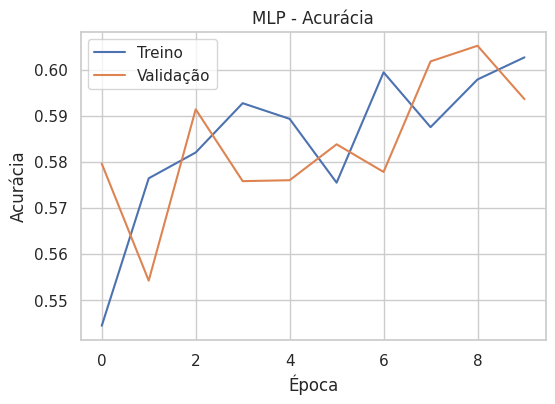

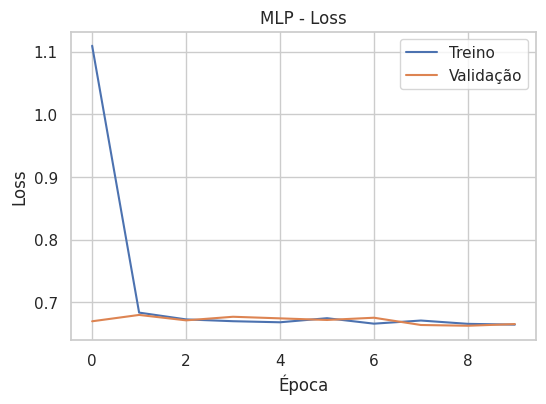

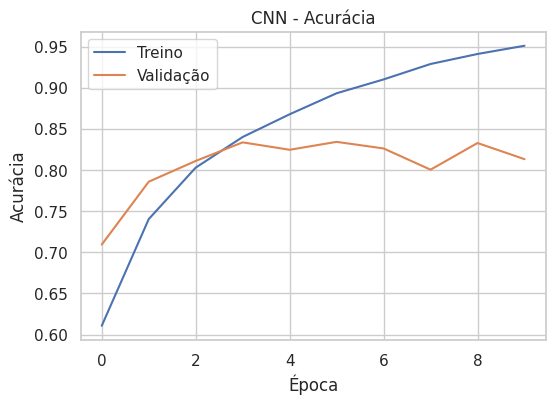

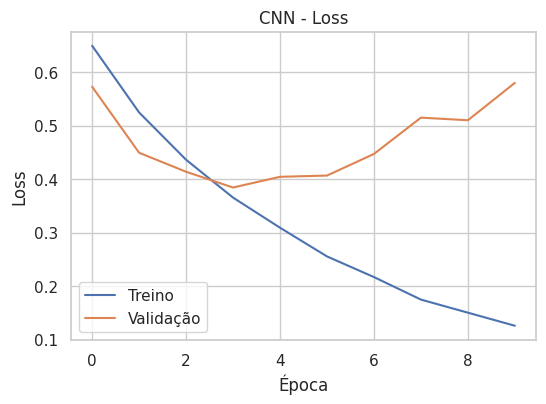

In [ ]:



# MLP - Acurácia

plt.figure(figsize=(6,4))
plt.plot(history_mlp.history['accuracy'], label='Treino')
plt.plot(history_mlp.history['val_accuracy'], label='Validação')
plt.title('MLP - Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()


# MLP - Loss

plt.figure(figsize=(6,4))
plt.plot(history_mlp.history['loss'], label='Treino')
plt.plot(history_mlp.history['val_loss'], label='Validação')
plt.title('MLP - Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# CNN - Acurácia

plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['accuracy'], label='Treino')
plt.plot(history_cnn.history['val_accuracy'], label='Validação')
plt.title('CNN - Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()


# CNN - Loss

plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['loss'], label='Treino')
plt.plot(history_cnn.history['val_loss'], label='Validação')
plt.title('CNN - Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Comente (B.6):** qual rede se saiu melhor em imagem? Por que isso acontece? Conecte com o que vimos sobre a CNN respeitar a estrutura espacial da imagem e a MLP não. _(escreva)_

A CNN se saiu significativamente melhor na classificação de imagens de cães e gatos porque as CNNs são projetadas especificamente para processar dados com uma estrutura espacial, como imagens. Elas utilizam camadas convolucionais que aplicam filtros para extrair características locais, como bordas, texturas e padrões, de diferentes partes da imagem. Ao contrário, a MLP achata a imagem em um vetor unidimensional  antes de processá-la. Ao fazer isso, a MLP perde completamente a informação da estrutura espacial e a relação entre pixels vizinhos, que é crucial para o reconhecimento de padrões visuais em imagens. Portanto, a capacidade da CNN de preservar e explorar essa estrutura hierárquica e espacial é a razão fundamental para seu desempenho superior em tarefas de visão computacional.

## B.7 Conclusão da Parte B

Escreva um parágrafo (5 a 8 linhas):
1. A diferença entre MLP e CNN em imagem ficou clara nos seus resultados?
2. Por que a CNN é mais adequada pra imagens que a MLP?
3. Juntando as duas partes da AV1: o que você conclui sobre "qual modelo/arquitetura usar pra qual tipo de dado"? (na Parte A, árvores ganharam em dado tabular; na Parte B, CNN ganhou em imagem)

A diferença de desempenho entre a MLP e a CNN em tarefas de classificação de imagens ficou notavelmente clara nos resultados obtidos. Enquanto a MLP apresentou uma acurácia de validação próxima a 60%, a CNN superou-a significativamente, atingindo cerca de 81-83%. Essa superioridade da CNN se deve à sua arquitetura especializada, que utiliza camadas convolucionais para extrair e preservar características espaciais das imagens, como bordas e texturas, algo que a MLP falha em fazer ao "achatar" os dados de entrada. Concluindo a AV1, percebe-se que a escolha do modelo/arquitetura é intrinsecamente ligada ao tipo de dado: para dados tabulares, modelos baseados em árvores (como XGBoost) demonstraram maior eficácia, capturando relações não lineares; já para dados de imagem, as CNNs são indiscutivelmente mais adequadas devido à sua capacidade de processar a estrutura espacial inerente a esses dados.

---

## Fim da AV1

Confira que respondeu todos os campos de comentário (eles valem tanto quanto o código), salve como `AV1_seunome.ipynb` e suba no AVA dentro do prazo.
